In [ ]:
print("Hello World")

Hello World


In [2]:
import torch
import torch.distributions as dist

In [ ]:
bernoulli = dist.Bernoulli(torch.tensor([0.5]))

In [ ]:
samples = [bernoulli.sample() for _ in range(1000)]
print(f"Mean: {torch.mean(torch.stack(samples))}")
print(f"Variance: {torch.var(torch.stack(samples))}")

Mean: 0.4970000088214874
Variance: 0.2502412497997284


In [ ]:
normal = dist.Normal(torch.tensor([0.0]), torch.tensor([1.0]))
samples = [normal.sample() for _ in range(1000)]
print(f"Mean: {torch.mean(torch.stack(samples))}")
print(f"Variance: {torch.var(torch.stack(samples))}")

Mean: -0.027469173073768616
Variance: 0.910779595375061


In [1]:
import torch
import torchvision
from PIL import Image

# Create a vector of zeros of size 5
size = (128, 128)
transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()])
train_dataset = list(torchvision.datasets.Flowers102("/tmp/flowers", "train", transform=transform, download=True))
test_dataset = list(torchvision.datasets.Flowers102("/tmp/flowers", "test", transform=transform, download=True))

# each data in the above dataset is composed to image details(index 0) and category (index 1)
# index 0 is a 3-d list of all the x-y coordinates with each coordinat having RGB values as a list

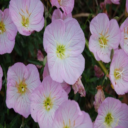

In [8]:
def visualize_image(img: torch.Tensor) -> Image.Image:
    return Image.fromarray((img.permute(1, 2, 0) * 255).to(torch.uint8).numpy())

# print the first image
visualize_image(train_dataset[0][0])

In [11]:
class_01 = train_dataset[:20]

In [25]:
def nn_classifier(x):
    dist = [((x - im).pow(2).sum(), lbl) for im, lbl in class_01]
    return min(dist)[1]

In [26]:
classifier = nn_classifier(test_dataset[0][0])
print(classifier)


1


In [27]:
# True is 1, False is 0. So in the below if all was right classification, accuracy will be 1
accuracy = sum(nn_classifier(im) == lbl for im,  lbl in test_dataset[:20]) / 20
print(accuracy)

0.4


In [34]:
def knn_classifier(x, k=3):
    dist = [((x - im).pow(2).sum(), lbl) for im, lbl in class_01]
    k_closest = [lbl for _, lbl in sorted(dist)[:k]]
    return sorted(k_closest)[k // 2] # k//2 just refer to the middle element in k_closest possibility

In [36]:
# knn_classifier(test_dataset[3][0])
accuracy = sum(knn_classifier(x) == lbl for x, lbl in test_dataset[:20]) / 20
print(accuracy)

0.5


In [39]:
def knn_regression(x, k=3):
    dist = [((x - im).pow(2).sum(), lbl) for im, lbl in class_01]
    k_closest = [lbl for _, lbl in sorted(dist)[:k]]
    print(k_closest)
    return torch.mean(torch.tensor(k_closest).float())


knn_regression(test_dataset[3][0])

[0, 1, 1]


tensor(0.6667)

In [48]:
# a row tensor with value as 1,2,3
a=torch.tensor([1,2,3], dtype=torch.float32)
print(a, type(a))

tensor([1., 2., 3.]) <class 'torch.Tensor'>


In [49]:
# a 3x3x3 tensor with random values
b = torch.rand([3, 3, 3], dtype=torch.float32)
print(b, type(b))

tensor([[[0.8853, 0.8140, 0.4042],
         [0.5923, 0.3285, 0.4206],
         [0.6667, 0.0961, 0.5179]],

        [[0.3148, 0.2707, 0.7392],
         [0.6826, 0.3502, 0.5435],
         [0.4917, 0.4596, 0.2165]],

        [[0.0432, 0.4205, 0.2422],
         [0.7016, 0.8876, 0.3551],
         [0.7905, 0.4604, 0.4593]]]) <class 'torch.Tensor'>


In [51]:
import numpy as np
from PIL import Image



torch.float32


In [55]:
img = Image.open("tulika.jpg")
#opens up image in the prompt
img
# opens up image in a separate window
img.show()


<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=4128x3096 at 0x7FA413FE38B0>


In [57]:
c = torch.as_tensor(np.array(img), dtype=torch.float32)
print(c.dtype)

torch.float32


In [59]:
a = torch.arange(10) # row/vector which has values sequential from 0 to n-1
b = torch.ones(10)
print(f"{a = }")
print(f"{b = }")
print(f"{a * (2 * b) = }") # dot product or one on one product
print(f"{a ** (2 * b) = }") # a^(2b) dot product or one on one product

a = tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
b = tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
a * (2 * b) = tensor([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18.])
a ** (2 * b) = tensor([ 0.,  1.,  4.,  9., 16., 25., 36., 49., 64., 81.])


In [4]:
a = torch.rand(100_000_000)
b = torch.rand(100_000_000)


In [ ]:
%timeit c = a + b

In [5]:
a_gpu = a.to("cuda")
b_gpu = b.to("cuda")
%timeit c_gpu = a_gpu + b_gpu

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx